# **CDS Project: Part 3**

*Institute of Software Security (E22)*  
*Hamburg University of Technology*  

## Learning objectives
---

- Choose an ML model architecture for vulnerability prediction
- Preprocess the dataset you created in project part 2 to fit the model you selected
- Split the dataset for cross validation
- Create the model training pipeline, train the model using the train set and optimize the model using the test set
- Create loss graphs of the learning behaviour
- Generate predictions for the validation set
- Evaluate the results using appropriate metrics (add questions: reduce overfitting? optional 5-fold cross validation)


## Materials
---

- Lecture Slides 2, 3, 5 and 6, 9.
- PyTorch Documentation: [Datasets and Data Loaders](https://pytorch.org/tutorials/beginner/basics/data_tutorial.html) 
- 


## Project Description

In this project, you will create, train and evaluate your own machine learning model to predict vulnerabilities in source code. In addition, you will preprocess the data to prepare it to be used in the learning pipeline.
You will be using the dataset created in part 2 in this part. 

## **Task 1**

- There are several ML model architectures that you can use for vulnerabilitiy prediction such as RNN, CNN, Multilabel Perceptron (MLP), Gated Recurrent Units (GRU) and so on. Choose a suitable ML model architecture for your project based on the strenghts and weaknesses of these algorithms.

- For the model architecture, you can choose from 2 paths:
  1. Preprocess the functions into vectors and continue the learning process similar to project 1.
  For instance, the code in the dataset needs to be converted into some type of vector representation that can be processed by a machine. After selecting a suitable model, preprocess the content in your dataset accordingly. Several models are available to preprocess code data such as:
    - Code2Vec: https://code2vec.org/
    - CodeBERT: https://github.com/microsoft/CodeBERT/tree/master/UniXcoder
    - CodeT5: https://github.com/salesforce/CodeT5

  2. Choose a model architecture that is capable of handeling raw text inputs (LSTM, GRU, etc.) as an input layer. Further information on text processing using pytorch:
    - https://pytorch.org/text/stable/index.html
    - https://pytorch.org/tutorials/


## Task 2

- Split your dataset appropriately into train, test, and validation set and justify your split.  

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 42

# File path of the dataset.
file_path = '/home/huso/Desktop/Cybersecurity Data Science/Lab 3/vulnerability_dataset.csv'


# Read the dataset from the csv file.
df = pd.read_csv(file_path)

print(df.head(20))


# Remove duplicated rows from the dataset.
df = df.drop_duplicates().reset_index(drop=True)


# Remove functions that have different labels.
# These samples can confuse the model because the same code has multiple labels.
label_nunique = df.groupby("function_code")["vulnerable"].nunique()

ambiguous_codes = label_nunique[label_nunique > 1].index

df_clean = df[~df["function_code"].isin(ambiguous_codes)].reset_index(drop=True)

print(f"Removed {len(ambiguous_codes)} ambiguous functions "
      f"({len(df) - len(df_clean)} rows). Remaining rows: {len(df_clean)}")


# Create a dataset with unique functions for splitting.
# This prevents the same function appearing in different sets.
unique_functions = (
    df_clean.drop_duplicates(subset="function_code")[["function_code", "vulnerable"]]
    .reset_index(drop=True)
)


# Split data into training and temporary sets.
# Stratify keeps the vulnerable/non-vulnerable ratio similar.
train_funcs, temp_funcs = train_test_split(
    unique_functions,
    test_size=0.30,
    stratify=unique_functions["vulnerable"],
    random_state=SEED
)


# Split the temporary set into validation and test sets.
val_funcs, test_funcs = train_test_split(
    temp_funcs,
    test_size=0.50,
    stratify=temp_funcs["vulnerable"],
    random_state=SEED
)


# Create final train, validation, and test datasets.
train_set = df_clean[df_clean["function_code"].isin(train_funcs["function_code"])].reset_index(drop=True)

val_set = df_clean[df_clean["function_code"].isin(val_funcs["function_code"])].reset_index(drop=True)

test_set = df_clean[df_clean["function_code"].isin(test_funcs["function_code"])].reset_index(drop=True)


# Check that there is no overlap between datasets.
# The same function should not exist in more than one split.
assert set(train_set["function_code"]) & set(val_set["function_code"]) == set()

assert set(train_set["function_code"]) & set(test_set["function_code"]) == set()

assert set(val_set["function_code"]) & set(test_set["function_code"]) == set()


# Print dataset sizes and vulnerable class distribution.
for name, s in [("Train", train_set), ("Validation", val_set), ("Test", test_set)]:
    print(f"{name}: {len(s)} rows ({len(s) / len(df_clean) * 100:.1f}%), "
          f"vulnerable={s['vulnerable'].mean() * 100:.1f}%")

Removed 456 ambiguous functions (912 rows). Remaining rows: 11185
Train: 7829 rows (70.0%), vulnerable=42.7%
Validation: 1678 rows (15.0%), vulnerable=42.7%
Test: 1678 rows (15.0%), vulnerable=42.7%


## Task 3
- Create a preprocessing and training/test pipeline. This can also be done in separate steps.
- Train the model on a small dataset (e.g.: 1000 samples depending on the computational capacity) and make sure everything is working properly
- Show a graph showing the changes in loss function druring the training epochs 
- Select proper metrics to evaluate the performance of the model
- If everything works well, then change the model parameters (e.g: number of neurons, layer depth) and regenerate the results. Comapare these results with your previous results and elaborate your findings.

In [40]:
# TODO: Implement your ML pipeline and perform evaluation

import re
from collections import Counter

def tokenize_code(code: str):
    # Splits Java code into meaningful tokens: identifiers, numbers, operators, punctuation
    tokens = re.findall(r'[a-zA-Z_]\w*|[0-9]+|[^\s\w]', code)
    return tokens

def build_vocab(texts, max_vocab_size=10000, min_freq=2):
    counter = Counter()
    for text in texts:
        counter.update(tokenize_code(text))
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, freq in counter.most_common(max_vocab_size - 2):
        if freq >= min_freq:
            vocab[word] = len(vocab)
    return vocab

# Vocab should only be built from the train_set (don't look at val/test)
train_unique = train_set.drop_duplicates(subset="function_code").reset_index(drop=True)
print(f"Train unique: {len(train_unique)} (before: {len(train_set)})")

vocab = build_vocab(train_unique["function_code"], max_vocab_size=15000, min_freq=2)
print(f"Vocabulary size: {len(vocab)}")

Train unique: 7829 (before: 7829)
Vocabulary size: 15000


In [ ]:
# I check token frequencies to choose a suitable vocabulary size.
# This shows which tokens are common and which are rare.all_tokens = []

for code in train_unique['function_code']:
    all_tokens.extend(re.findall(r'[a-zA-Z_]\w*|[0-9]+|[^\s\w]', code))

counter = Counter(all_tokens)
print(f"Total unique tokens: {len(counter)}")
print(f"Top 20 most common tokens: {counter.most_common(20)}")
print(f"Tokens appearing only once: {sum(1 for v in counter.values() if v == 1)}")
print(f"Tokens appearing 2+ times: {sum(1 for v in counter.values() if v >= 2)}")
print(f"Tokens appearing 5+ times: {sum(1 for v in counter.values() if v >= 5)}")
print(f"Tokens appearing 10+ times: {sum(1 for v in counter.values() if v >= 10)}")

Total unique tokens: 39761
Top 20 most common tokens: [('(', 275136), (')', 275020), ('.', 220100), (';', 149756), ('"', 134992), (',', 117778), ('=', 92050), ('{', 64776), ('}', 64606), ('/', 58382), ('if', 24448), ('new', 24432), ('+', 23924), ('String', 21416), (':', 20920), ('>', 17404), ('null', 16566), ('<', 16134), ('-', 15730), ('!', 14362)]
Tokens appearing only once: 0
Tokens appearing 2+ times: 39761
Tokens appearing 5+ times: 21217
Tokens appearing 10+ times: 13510


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch

# Maximum sequence length for each code sample.
MAX_LEN = 512


# Custom dataset class to prepare code data for the model.
class CodeDataset(Dataset):

    # Initialize dataset with code samples, labels, and vocabulary.
    def __init__(self, df, vocab, max_len=MAX_LEN):
        df_clean = df.dropna(subset=["function_code"])

        # Store labels as integer values.
        self.labels = df_clean['vulnerable'].astype(int).tolist()

        self.vocab = vocab
        self.max_len = max_len

        # Convert code tokens into numerical ids.
        self.data = []

        for code in df_clean['function_code']:

            # Tokenize code and limit sequence length.
            tokens = tokenize_code(code)[:max_len]

            # Convert tokens into vocabulary ids.
            ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]

            # Add padding if the sequence is shorter than max length.
            ids += [vocab['<PAD>']] * (max_len - len(ids))

            self.data.append(ids)


    # Return the number of samples in the dataset.
    def __len__(self):
        return len(self.data)


    # Return one sample and its label.
    def __getitem__(self, idx):

        # Convert data into tensors when loading each sample.
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.float)


# Create dataset objects for training, validation, and testing.
# All samples use the same maximum length of 512 tokens.
train_dataset = CodeDataset(train_unique, vocab, max_len=MAX_LEN)
val_dataset   = CodeDataset(val_set,      vocab, max_len=MAX_LEN)
test_dataset  = CodeDataset(test_set,     vocab, max_len=MAX_LEN)


# Create data loaders to provide data in batches.
# Shuffle is used only for training to improve learning.
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False)


# Show the number of batches in each dataset.
print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 245, Val batches: 53, Test batches: 53


In [ ]:
import torch.nn as nn

# Select GPU if available, otherwise use CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# Simple GRU model for binary classification.
# The model learns patterns from token sequences.
class GRUClassifier(nn.Module):

    # Define model layers.
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()

        # Convert token ids into embedding vectors.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # GRU learns relationships between tokens in the sequence.
        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=False
        )

        # Dropout helps reduce overfitting.
        self.dropout = nn.Dropout(dropout)

        # Final layer makes the classification prediction.
        self.fc = nn.Linear(hidden_dim, 1)


    def forward(self, x):

        # Convert input tokens to embeddings.
        embedded = self.dropout(self.embedding(x))

        # Pass embeddings through GRU.
        _, hidden = self.gru(embedded)

        # Use the last hidden state for prediction.
        out = self.dropout(hidden[-1])

        # Return final model output.
        return self.fc(out).squeeze(1)


# Initial parameters for a small and quick test.
# These values are used to create a simple baseline model.
VOCAB_SIZE  = len(vocab)
EMBED_DIM   = 64
HIDDEN_DIM  = 128
NUM_LAYERS  = 1
DROPOUT     = 0.3


# Create the GRU model and move it to the selected device.
model = GRUClassifier(
    VOCAB_SIZE, 
    EMBED_DIM, 
    HIDDEN_DIM, 
    NUM_LAYERS, 
    DROPOUT
).to(device)


# Print model structure and number of trainable parameters.
print(model)
print(f"\nTrainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Using device: cpu
GRUClassifier(
  (embedding): Embedding(15000, 64, padding_idx=0)
  (gru): GRU(64, 128, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=128, out_features=1, bias=True)
)

Trainable parameters: 1,034,625


Trainable parameters: 2,611,714
pos_weight: 1.3433
  batch 0/245 - loss: 0.7497
  batch 20/245 - loss: 0.8613
  batch 40/245 - loss: 0.7978
  batch 60/245 - loss: 0.7993
  batch 80/245 - loss: 0.7731
  batch 100/245 - loss: 0.7902
  batch 120/245 - loss: 0.8229
  batch 140/245 - loss: 0.7986
  batch 160/245 - loss: 0.7876
  batch 180/245 - loss: 0.7985
  batch 200/245 - loss: 0.7821
  batch 220/245 - loss: 0.8044
  batch 240/245 - loss: 0.7885
Epoch 01 | train_loss: 0.7951 | val_loss: 0.7945 | val_acc: 0.5638 | val_f1: 0.0639 | val_auc: 0.5357
  batch 0/245 - loss: 0.8017
  batch 20/245 - loss: 0.8018
  batch 40/245 - loss: 0.8102
  batch 60/245 - loss: 0.8062
  batch 80/245 - loss: 0.7858
  batch 100/245 - loss: 0.7702
  batch 120/245 - loss: 0.7884
  batch 140/245 - loss: 0.7619
  batch 160/245 - loss: 0.7620
  batch 180/245 - loss: 0.8399
  batch 200/245 - loss: 0.7939
  batch 220/245 - loss: 0.7956
  batch 240/245 - loss: 0.8211
Epoch 02 | train_loss: 0.7947 | val_loss: 0.7947 | va

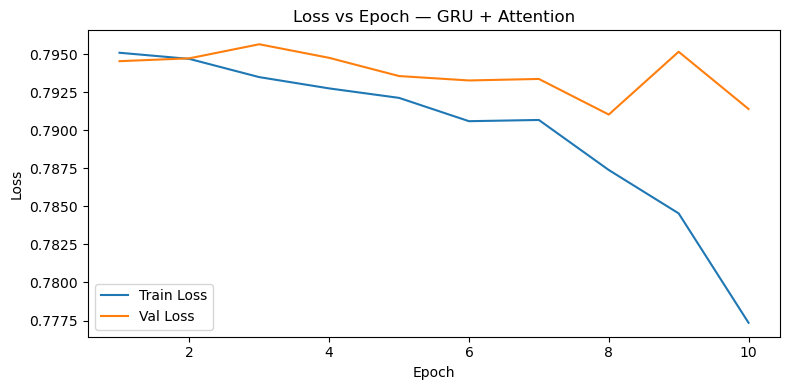

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# This function trains the model for one epoch.
# It updates the model weights using the training data.
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    # Go through each batch and calculate the loss.
    for i, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        # Clear previous gradients and make a prediction.
        optimizer.zero_grad()
        preds = model(X)

        # Calculate loss and update model parameters.
        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        # Print training progress.
        if i % 20 == 0:
            print(f"  batch {i}/{len(loader)} - loss: {loss.item():.4f}")

    return total_loss / len(loader)


from sklearn.metrics import precision_score, recall_score

# This function evaluates the model on validation data.
# It calculates different metrics to check model performance.
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    # Disable gradient calculation because we only evaluate the model.
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)

            # Get predictions from the model.
            logits = model(X)

            # Calculate validation loss.
            loss = criterion(logits, y)
            total_loss += loss.item()

            # Convert outputs into probabilities.
            probs = torch.sigmoid(logits).cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(y.cpu().numpy())

    # Convert probabilities into binary predictions.
    avg_loss = total_loss / len(loader)
    binary_preds = [1 if p >= 0.5 else 0 for p in all_preds]

    # Calculate evaluation metrics.
    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, binary_preds),
        "precision": precision_score(all_labels, binary_preds, zero_division=0),
        "recall": recall_score(all_labels, binary_preds, zero_division=0),
        "f1": f1_score(all_labels, binary_preds, zero_division=0),
        "auc": roc_auc_score(all_labels, all_preds)
    }

    return metrics


# GRU model with an attention layer for vulnerability detection.
# Attention helps the model focus on important parts of the input.
class GRUWithAttention(nn.Module):

    # Initialize model layers.
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers, dropout=0.3):
        super().__init__()

        # Convert token ids into dense vector representations.
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # GRU learns patterns from the sequence of tokens.
        self.gru = nn.GRU(embed_dim, hidden_dim, num_layers=num_layers,
                          batch_first=True,
                          dropout=dropout if num_layers > 1 else 0.0)

        # Attention layer decides which tokens are more important.
        self.attention = nn.Linear(hidden_dim, 1)

        # Dropout helps prevent overfitting.
        self.dropout = nn.Dropout(dropout)

        # Final layer makes the binary classification prediction.
        self.fc = nn.Linear(hidden_dim, 1)


    def forward(self, x):

        # Convert input tokens into embeddings.
        embedded = self.dropout(self.embedding(x))

        # Process the sequence using GRU.
        outputs, _ = self.gru(embedded)

        # Calculate attention weights for each token.
        attn_weights = torch.softmax(self.attention(outputs), dim=1)

        # Create a context vector using important token information.
        context = (attn_weights * outputs).sum(dim=1)

        # Return final prediction.
        return self.fc(self.dropout(context)).squeeze(1)


# Calculate class weight because the dataset is imbalanced.
# This gives more importance to the smaller class.
pos_weight = torch.tensor([
    len(train_unique[train_unique["vulnerable"] == False]) /
    len(train_unique[train_unique["vulnerable"] == True])
]).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)


# Create the GRU + Attention model.
model = GRUWithAttention(
    vocab_size=len(vocab),
    embed_dim=128,
    hidden_dim=256,
    num_layers=2,
    dropout=0.4
).to(device)


# Adam optimizer is used to update model weights.
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4, weight_decay=1e-4)

# Reduce learning rate when validation loss stops improving.
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, patience=2, factor=0.5
)


# Show model size and class weight information.
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"pos_weight: {pos_weight.item():.4f}")


# Train the model for multiple epochs and save losses.
EPOCHS = 10
train_losses, val_losses = [], []


for epoch in range(1, EPOCHS + 1):

    # Train model and evaluate validation performance.
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    val_metrics = eval_epoch(model, val_loader, criterion)

    # Update learning rate based on validation loss.
    scheduler.step(val_metrics["loss"])

    train_losses.append(train_loss)
    val_losses.append(val_metrics["loss"])


    # Print results after each epoch.
    print(f"Epoch {epoch:02d} | train_loss: {train_loss:.4f} | "
          f"val_loss: {val_metrics['loss']:.4f} | "
          f"val_acc: {val_metrics['accuracy']:.4f} | "
          f"val_f1: {val_metrics['f1']:.4f} | "
          f"val_auc: {val_metrics['auc']:.4f}")


# Plot training and validation loss changes.
# This helps to see if the model is learning well.
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, label="Train Loss")
plt.plot(range(1, EPOCHS + 1), val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss vs Epoch — GRU + Attention")
plt.legend()
plt.tight_layout()
plt.show()

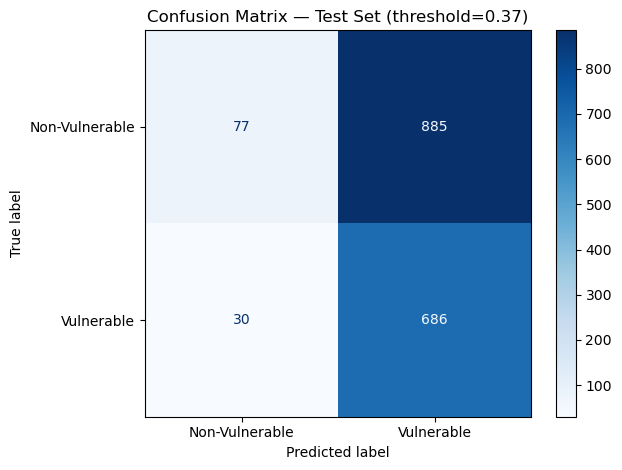

=== PERFORMANCE METRICS TABLE ===
Metric          Score
----------------------
Accuracy       0.4547
Precision      0.4367
Recall         0.9581
F1             0.5999
AUC            0.5457


In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion matrix
cm = confusion_matrix(all_labels_test, preds_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Vulnerable", "Vulnerable"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set (threshold=0.37)")
plt.tight_layout()
plt.show()

# Metrik tablosu
print("=== PERFORMANCE METRICS TABLE ===")
print(f"{'Metric':<12} {'Score':>8}")
print("-" * 22)
print(f"{'Accuracy':<12} {accuracy_score(all_labels_test, preds_test):>8.4f}")
print(f"{'Precision':<12} {precision_score(all_labels_test, preds_test, zero_division=0):>8.4f}")
print(f"{'Recall':<12} {recall_score(all_labels_test, preds_test, zero_division=0):>8.4f}")
print(f"{'F1':<12} {f1_score(all_labels_test, preds_test, zero_division=0):>8.4f}")
print(f"{'AUC':<12} {roc_auc_score(all_labels_test, all_probs_test):>8.4f}")

In [ ]:
import json

class ChallengeJSONLDataset(Dataset):
    def __init__(self, jsonl_path, vocab, max_len=MAX_LEN):
        self.vocab = vocab
        self.max_len = max_len
        self.vul_ids = []
        self.data = []
        
        with open(jsonl_path, 'r', encoding='utf-8') as f:
            for line in f:
                if not line.strip():
                    continue
                item = json.loads(line)
                
                v_id = item.get('vul_id')
                code = item.get('func') or item.get('function_code') or item.get('code') 
                
                self.vul_ids.append(v_id)
                
                tokens = tokenize_code(str(code))[:max_len]
                ids = [vocab.get(t, vocab['<UNK>']) for t in tokens]
                ids += [vocab['<PAD>']] * (max_len - len(ids))
                self.data.append(ids)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), self.vul_ids[idx]

challenge_dataset = ChallengeJSONLDataset("/home/huso/Downloads/cds_challenge.jsonl", vocab, max_len=MAX_LEN)
challenge_loader = DataLoader(challenge_dataset, batch_size=32, shuffle=False)

In [43]:
model.eval()

submission_ids = []
submission_preds = []

with torch.no_grad():
    for X, vul_ids in challenge_loader:
        X = X.to(device)
        logits = model(X)
        probs = torch.sigmoid(logits).cpu().numpy()
        
        binary_preds = [True if p >= 0.37 else False for p in probs]
        
        if isinstance(vul_ids, torch.Tensor):
            clean_ids = vul_ids.cpu().numpy().astype(int).tolist()
        else:
            # If the items in the list are tensors, clear them one by one
            clean_ids = [int(v.item()) if hasattr(v, 'item') else int(v) for v in vul_ids]
            
        submission_ids.extend(clean_ids)
        submission_preds.extend(binary_preds)


challenge_results_df = pd.DataFrame({
    'vul_id': submission_ids,
    'is_vul': submission_preds
})

# Save the file directly to the Downloads folder with clean int values
challenge_results_df.to_csv("/home/huso/Downloads/cds_submission.csv", index=False)
print("The new file has been saved to the Downloads folder with clean int values!")

The new file has been saved to the Downloads folder with clean int values!
